# Fake News Detection Using NLP

## Project Category
Natural Language Processing (NLP)

---

## Objective

The objective of this project is to detect whether a news article is fake or real using Natural Language Processing (NLP) and machine learning techniques.

This project aims to:
- preprocess textual news data,
- apply TF-IDF vectorization,
- train classification models,
- evaluate fake news detection performance,
- analyze misinformation patterns.

---

## Dataset Information

The dataset is divided into two separate files:

- `Fake.csv` → contains 23,502 fake news articles
- `True.csv` → contains 21,417 real news articles

### Dataset Columns

- `title` → Title of the news article
- `text` → Main body/content of the news article
- `subject` → Topic/category of the news article
- `date` → Publication date of the news article

The dataset is commonly used for NLP and fake news detection tasks.

---

## Algorithms Used

- TF-IDF Vectorization
- Logistic Regression
- Naive Bayes
- Random Forest Classifier

---

## Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

---

## Project Workflow

1. Data Understanding
2. Data Cleaning
3. Text Preprocessing
4. TF-IDF Vectorization
5. Train-Test Split
6. Model Training
7. Model Evaluation
8. Confusion Matrix
9. Conclusion

In [7]:
from google.colab import files

uploaded = files.upload()

Saving Fake.csv to Fake (1).csv
Saving True.csv to True.csv


In [8]:
import pandas as pd

fake_df = pd.read_csv("Fake.csv")

true_df = pd.read_csv("True.csv")

In [9]:
print("Fake Shape:", fake_df.shape)

print("True Shape:", true_df.shape)

Fake Shape: (23481, 4)
True Shape: (21417, 4)


In [10]:
fake_df["Label"] = 1

true_df["Label"] = 0

In [11]:
df = pd.concat(
    [fake_df, true_df],
    axis=0)

In [12]:
df = df.sample(
    frac=1,
    random_state=42)

In [13]:
df.reset_index(
    drop=True,
    inplace=True)

In [14]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (44898, 5)

Columns:
Index(['title', 'text', 'subject', 'date', 'Label'], dtype='object')

Data Types:
title      object
text       object
subject    object
date       object
Label       int64
dtype: object

Missing Values:
title      0
text       0
subject    0
date       0
Label      0
dtype: int64

Duplicate Rows:
209


In [15]:
df = df.drop_duplicates()

In [16]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [17]:
df["content"] = (
    df["title"] + " " + df["text"])

In [18]:
df["Content_Length"] = df["content"].apply(len)

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

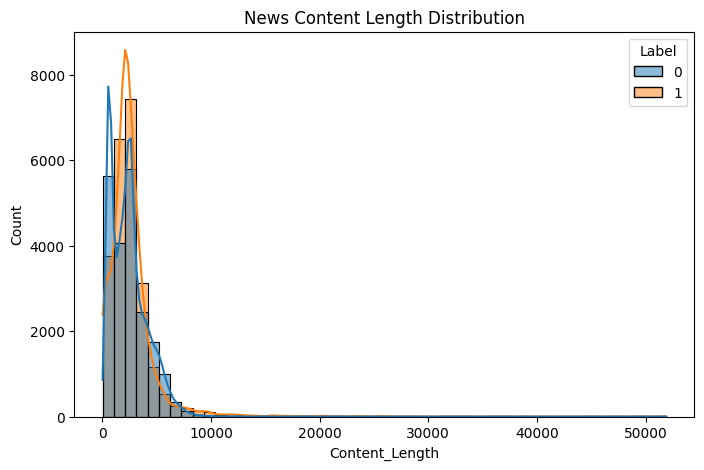

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Content_Length",
    hue="Label",
    bins=50,
    kde=True)

plt.title("News Content Length Distribution")

plt.show()

###MODELLEME

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

X = df["content"]

y = df["Label"]

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000)

X_tfidf = vectorizer.fit_transform(X)

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [26]:
from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import MultinomialNB

from sklearn.ensemble import RandomForestClassifier

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score)

import pandas as pd

In [28]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Naive Bayes":
        MultinomialNB(),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42)}

In [29]:
results = []

for model_name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({

        "Model": model_name,

        "Accuracy":
            accuracy_score(y_test, y_pred),

        "Precision":
            precision_score(y_test, y_pred),

        "Recall":
            recall_score(y_test, y_pred),

        "F1 Score":
            f1_score(y_test, y_pred)})

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.987469,0.990582,0.985520,0.988044
1,Naive Bayes,0.933654,0.933446,0.940801,0.937109
2,Random Forest,0.997762,0.997659,0.998083,0.997871


In [30]:
best_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

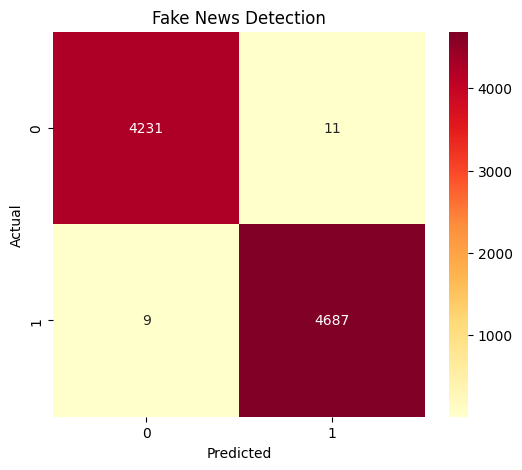

In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlOrRd")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Fake News Detection")

plt.show()

## Confusion Matrix Analysis

The confusion matrix demonstrates extremely strong fake news classification performance.

### Results
- 4231 real news articles were correctly classified.
- 4687 fake news articles were correctly detected.
- Only 11 real news articles were incorrectly classified as fake.
- Only 9 fake news articles were missed by the model.

### Interpretation

The Random Forest classifier achieved near-perfect fake news detection performance with extremely low classification error.

The model successfully distinguished fake and real news articles using TF-IDF vectorization and machine learning techniques.

These results demonstrate the effectiveness of NLP-based text classification methods for misinformation detection.